In [102]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import logging
from patsy import bs
import itertools

# Setup logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


In [ ]:
# Configuration
base_path = Path('/home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node')
parent_dir_name = 'full_all_departement_0_None_node'

scale = 10
horizon = 0

models = [
    #'DilatedCNN_search_full_10_0_all_one_',
    'GRU_search_full_10_0_all_one_',
    #'LSTM_search_full_10_0_all_one_',
    #'NetMLP_search_full_10_0_all_one_',
    #'NetMLP_search_full_0_0_all_one_',
    #'graphCastGRU_search_full_10_0_all_one_',
    #'graphCastGRUWithAttentionGAT_search_full_10_0_all_one_'
]

losses = [
    'classification_wkloss',
    'classification_bceloss',
    'classification_weightedcrossentropy',
    'regression_pdegpd',
    'classification_flwk',
    'classification_flwki-id{departement}',
]

targets = [
   'nbsinister-kmeans-5-Class-Dept',
]

clustering = 'kmeans'

all_dir = list(itertools.product(models, losses, targets))

def find_directories(base_path):
    matches = []
    if not base_path.exists():
        print(f"Base path does not exist: {base_path}")
        return []

    for (model, loss, target) in all_dir:
        # Construct exact directory name: model + target + '_' + loss
        # Note: model strings already include the trailing underscore
        dir_name = f"{model}{target}_{loss}"
        full_path = base_path / dir_name
        
        if full_path.exists() and full_path.is_dir():
            matches.append((full_path, model, loss, target))
        # else:
        #     print(f"Directory not found: {dir_name}")
            
    return matches

directories = find_directories(base_path)
print(f"Found {len(directories)} directories matching configuration.")

Found 6 directories matching configuration.


In [104]:
data_frames = {}
gt_dfs = {}
target_cols = {}

print(f"Found {len(directories)} directories.")

for d, model, loss, target in directories:
    
    if target is None:
        # Try to guess target or skip
        continue

    # Load pickle
    # Search for pickle in H0 subdirectory or current directory
    pkl_files = []
    h0_path = os.path.join(d, "H0")
    if os.path.exists(h0_path):
        pkl_files.extend([os.path.join(h0_path, f) for f in os.listdir(h0_path) if f.endswith(".pkl")])
    
    if not pkl_files:
        pkl_files.extend([os.path.join(d, f) for f in os.listdir(d) if f.endswith(".pkl")])
        
    if not pkl_files:
        # print(f"Skipping {d}: no pickle found")
        continue
        
    # Use the first pickle found (assuming one relevant pickle per dir)
    file_path = pkl_files[0]
        
    try:
        with open(file_path, "rb") as f:
            res = pd.read_pickle(f)
    except Exception as e:
        print(f"Error loading {d}: {e}")
        continue

    # Ensure required columns
    if "date" not in res.columns or "graph_id" not in res.columns:
        print(f"Skipping {d}: missing date or graph_id")
        continue
        
    # Identify prediction column
    # Usually 'prediction' or the target name itself if it's a baseline, 
    # but for models it's often 'prediction' or 'output'.
    # Let's check for 'prediction'
    pred_col = f"prediction_{target}_0"
    if pred_col not in res.columns:
        # Check if target column exists and use it (e.g. for perfect baseline)
        if target in res.columns:
            pred_col = target
        else:
            print(f"Skipping {d}: no prediction column")
            continue

    # Prepare dataframe for risk_all
    df = res[["date", "graph_id", target]].copy()
    df["risk_score"] = res[pred_col]
    df[pred_col] = res[pred_col]
    df["config"] = f"{model}{loss}" # Use directory name as config/model name
    
    if 'nbsinister' in target:
        df['nbsinister'] = res['nbsinister']
    else:
        df['burnedareaRoot'] = res['burnedareaRoot']
        
    df['num_zone'] = df['graph_id']
    
    data_frames[f"{model}{loss}"] = df
    
    # Store Ground Truth if not already stored for this target
    # OR if it is stored but missing the baseline column, and the current one has it.
    
    # Determine baseline column name (logic from monotonic_risk_score.py)
    baseline_col = f"{target}"

    has_baseline = baseline_col in res.columns
    
    cols_to_keep = ["date", "graph_id", "nbsinister", "burnedareaRoot"]
    if has_baseline:
        cols_to_keep.append(baseline_col)
        
    gt_df = res[["date", "graph_id", target]].copy()
    
    gt_df[pred_col] = gt_df[target]
    gt_df = res[cols_to_keep].copy()
    gt_df['num_zone'] = gt_df['graph_id']
    gt_dfs[target] = gt_df
    target_cols[target] = target
    
    if has_baseline:
        print(f"Loaded GT for {target} from {d} (with baseline)")
    else:
        print(f"Loaded GT for {target} from {d} (NO baseline)")
        
print(f"Loaded {len(data_frames)} configurations.")

if not data_frames:
    print("No data loaded. Please check paths and pickle files.")
else:
    risk_all = pd.concat(data_frames.values(), ignore_index=True)
    print("risk_all shape:", risk_all.shape)


Found 6 directories.
Loaded GT for nbsinister-kmeans-5-Class-Dept from /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node/GRU_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss (with baseline)
Loaded GT for nbsinister-kmeans-5-Class-Dept from /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node/GRU_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_bceloss (with baseline)
Loaded GT for nbsinister-kmeans-5-Class-Dept from /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node/GRU_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_weightedcrossentropy (with baseline)
Loaded GT for nbsinister-kmeans-5-Class-Dept from /home/caron/Bureau/ST-GNN-for-wildi

In [105]:
data_frames.keys()

dict_keys(['GRU_search_full_10_0_all_one_classification_wkloss', 'GRU_search_full_10_0_all_one_classification_bceloss', 'GRU_search_full_10_0_all_one_classification_weightedcrossentropy', 'GRU_search_full_10_0_all_one_regression_pdegpd', 'GRU_search_full_10_0_all_one_classification_flwk', 'GRU_search_full_10_0_all_one_classification_flwki-id{departement}'])

In [106]:
gt_dfs

{'nbsinister-kmeans-5-Class-Dept':        date  graph_id  nbsinister  burnedareaRoot  \
 0      2029       0.0         0.0             0.0   
 1      2030       0.0         0.0             0.0   
 2      2031       0.0         0.0             0.0   
 3      2032       0.0         0.0             0.0   
 4      2033       0.0         0.0             0.0   
 ...     ...       ...         ...             ...   
 33483  2388      93.0         0.0             0.0   
 33484  2389      93.0         0.0             0.0   
 33485  2390      93.0         0.0             0.0   
 33486  2391      93.0         0.0             0.0   
 33487  2392      93.0         0.0             0.0   
 
        nbsinister-kmeans-5-Class-Dept  num_zone  
 0                                   0       0.0  
 1                                   0       0.0  
 2                                   0       0.0  
 3                                   0       0.0  
 4                                   0       0.0  
 ...      

In [107]:
data_frames['GRU_search_full_10_0_all_one_classification_wkloss']

,date,graph_id,nbsinister-kmeans-5-Class-Dept,risk_score,prediction_nbsinister-kmeans-5-Class-Dept_0,config,nbsinister,num_zone
0,2029,0.0,0,0,0,GRU_search_full_10_0_all_one_classification_wk...,0.0,0.0
1,2030,0.0,0,0,0,GRU_search_full_10_0_all_one_classification_wk...,0.0,0.0
2,2031,0.0,0,0,0,GRU_search_full_10_0_all_one_classification_wk...,0.0,0.0
3,2032,0.0,0,0,0,GRU_search_full_10_0_all_one_classification_wk...,0.0,0.0
4,2033,0.0,0,0,0,GRU_search_full_10_0_all_one_classification_wk...,0.0,0.0
...,...,...,...,...,...,...,...,...
33483,2388,93.0,0,0,0,GRU_search_full_10_0_all_one_classification_wk...,0.0,93.0
33484,2389,93.0,0,0,0,GRU_search_full_10_0_all_one_classification_wk...,0.0,93.0
33485,2390,93.0,0,0,0,GRU_search_full_10_0_all_one_classification_wk...,0.0,93.0
33486,2391,93.0,0,0,0,GRU_search_full_10_0_all_one_classification_wk...,0.0,93.0


In [108]:
gt_dfs['nbsinister-kmeans-5-Class-Dept']

,date,graph_id,nbsinister,burnedareaRoot,nbsinister-kmeans-5-Class-Dept,num_zone
0,2029,0.0,0.0,0.0,0,0.0
1,2030,0.0,0.0,0.0,0,0.0
2,2031,0.0,0.0,0.0,0,0.0
3,2032,0.0,0.0,0.0,0,0.0
4,2033,0.0,0.0,0.0,0,0.0
...,...,...,...,...,...,...
33483,2388,93.0,0.0,0.0,0,93.0
33484,2389,93.0,0.0,0.0,0,93.0
33485,2390,93.0,0.0,0.0,0,93.0
33486,2391,93.0,0.0,0.0,0,93.0


In [109]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from patsy import bs

BASELINE_NAME = ""
SCORE_COL = "risk_score"
KEYS = ["date", "num_zone"]

# -----------------------------
# Long format builders
# -----------------------------
def build_long_scores_from_dfe_df(dfe_df: pd.DataFrame, config_name: str = "DFE_score") -> pd.DataFrame:
    d = dfe_df.copy()
    d["date"] = pd.to_datetime(d["date"])
    d["num_zone"] = d["num_zone"].astype(int)
    if "DFE" not in d.columns:
        raise ValueError("La colonne 'DFE' est absente de dfe_df.")
    out = d[KEYS + ["DFE"]].copy()
    out["config"] = config_name
    out = out.rename(columns={"DFE": "score"})
    return out

def build_long_scores_from_fwi(df: pd.DataFrame, config_name="FWI_score") -> pd.DataFrame:
    d = df.copy()
    d["date"] = pd.to_datetime(d["date"])
    d["num_zone"] = d["num_zone"].astype(int)
    if "fwi_mean" not in d.columns:
        raise ValueError("La colonne 'fwi_mean' est absente de dfe_df.")
    out = d[KEYS + ["fwi_mean"]].copy()
    out["config"] = config_name
    out = out.rename(columns={"fwi_mean": "score"})
    print(out)
    return out

def build_long_scores_configs(risk_all: pd.DataFrame) -> pd.DataFrame:
    d = risk_all.copy()
    d["date"] = pd.to_datetime(d["date"])
    d["num_zone"] = d["num_zone"].astype(int)

    if "config" not in d.columns:
        raise ValueError("risk_all doit contenir une colonne 'config'.")
    if SCORE_COL not in d.columns:
        raise ValueError(f"risk_all doit contenir la colonne '{SCORE_COL}'.")

    real = d[KEYS + ["config", SCORE_COL]].copy()
    return real.rename(columns={SCORE_COL: "score"})

def build_long_scores_h0_from_gt(gt_df: pd.DataFrame, y_col: str) -> pd.DataFrame:
    if y_col in ["nbsinister", "time_intervention", "ressource"]:
        if y_col == "time_intervention":
            baseline_col = "prediction_timeintervention-kmeans-5-Class-Dept_0"
        else:
            baseline_col = f"prediction_{y_col}-kmeans-5-Class-Dept_0"
    else:
        baseline_col = f"prediction_{y_col}_0"

    g = gt_df.copy()
    g["date"] = pd.to_datetime(g["date"])
    g["num_zone"] = g["num_zone"].astype(int)

    if baseline_col not in g.columns:
        raise ValueError(f"Colonne baseline '{baseline_col}' absente du dataframe target.")

    base = g[KEYS + [baseline_col]].copy()
    base["config"] = BASELINE_NAME
    base = base.rename(columns={baseline_col: "score"})
    return base

def prepare_long_for_target(
    risk_all: pd.DataFrame,
    gt_df: pd.DataFrame,
    y_col: str,
    add_dfe_score_as_config: bool = False,
    add_fwi_score_as_config: bool = False,
    dfe_df: pd.DataFrame | None = None,
    dfe_config_name: str = "DFE_score",
    fwi_config_name: str = "FWI_score",
    extra_scores: list[pd.DataFrame] | None = None,  # <-- NEW
) -> pd.DataFrame:
    real = build_long_scores_configs(risk_all)
    #h0 = build_long_scores_h0_from_gt(gt_df, y_col)
    parts = [real]

    # NEW: extra configs already in long format KEYS+config+score
    if extra_scores:
        parts.extend(extra_scores)

    if add_dfe_score_as_config:
        if dfe_df is None:
            raise ValueError("add_dfe_score_as_config=True mais dfe_df est None.")
        parts.append(build_long_scores_from_dfe_df(dfe_df, config_name=dfe_config_name))
    
    if add_fwi_score_as_config:
        parts.append(build_long_scores_from_fwi(gt_df, config_name=fwi_config_name))

    scores_long = pd.concat(parts, ignore_index=True)

    g = gt_df.copy()
    g["date"] = pd.to_datetime(g["date"])
    g["num_zone"] = g["num_zone"].astype(int)
    if y_col not in g.columns:
        raise ValueError(f"Colonne target '{y_col}' absente du dataframe target.")

    gt = g[KEYS + [y_col]].copy()
    merged = scores_long.merge(gt, on=KEYS, how="inner")
    merged = merged.dropna(subset=["score", y_col]).rename(columns={y_col: "Y"})
    return merged

def fit_spline_mu(dd: pd.DataFrame, df_spline: int = 5):
    d = dd.dropna(subset=["score", "Y", "num_zone", "date"]).copy()
    d["score"] = d["score"].clip(0, 4)

    formula = (
        f"Y ~ bs(score, df={df_spline}, degree=3, include_intercept=False, "
        f"lower_bound=0, upper_bound=4) + C(num_zone) + C(date)"
    )
    fit = smf.ols(formula, data=d).fit(cov_type="HC1")

    template = d[["score", "num_zone", "date"]].copy()
    mu = {}
    for s in LEVELS:
        tmp = template.copy()
        tmp["score"] = float(s)
        mu[s] = float(fit.predict(tmp).mean())
    return mu, fit

import pandas as pd

def get_spline_prediction(df: pd.DataFrame, x_col: str, y_col: str, df_spline: int = 5):
    """
    Fit a spline model Y ~ bs(X) + C(num_zone) + C(date) and return predictions.
    """
    d = df.dropna(subset=[x_col, y_col, "num_zone", "date"]).copy()
    d[x_col] = d[x_col].clip(0, 4)
    
    # Ensure num_zone and date are treated as categorical for fixed effects
    d["num_zone"] = d["num_zone"].astype("category")
    d["date"] = d["date"].astype("category")
    
    formula = (
        f"{y_col} ~ bs({x_col}, df={df_spline}, degree=3, include_intercept=False, "
        f"lower_bound=0, upper_bound=4) + C(num_zone) + C(date)"
    )
    fit = smf.ols(formula, data=d).fit(cov_type="HC1")
    
    # Predict on the original dataframe
    # We need to handle cases where some levels might be missing in df but present in d, 
    # but here we are predicting on the same df used for fitting (or a subset).
    preds = fit.predict(df)
    return preds.clip(0, 4).round().astype(int)

def compute_passage_metrics_for_config(
    d: pd.DataFrame,
    df_spline: int = 5,
    min_n: int = 1,
    EXTRAPOLATION: bool = False,
    min_pairs_k: int = 1,   # optionnel: nb min de passages valides par k
):
    dd = d.dropna(subset=["score", "Y"]).copy()
    dd["score"] = dd["score"].clip(0, 4)

    # niveaux discrets
    dd["_lvl"] = dd["score"].astype(int)

    # effectifs par niveau (0..4)
    lvl_counts = dd["_lvl"].value_counts().to_dict()
    support = set(lvl_counts.keys())

    mu, fit = fit_spline_mu(dd, df_spline=df_spline)

    if 4 in LEVELS:
        out = {
            "n": len(dd),
            "support": ",".join(map(str, sorted(support))),
            "mu0": mu[0], "mu1": mu[1], "mu2": mu[2], "mu3": mu[3], "mu4": mu[4],
        }
    else:
        out = {
            "n": len(dd),
            "support": ",".join(map(str, sorted(support))),
            "mu0": mu[0], "mu1": mu[1], "mu2": mu[2], "mu3": mu[3],
        }

    # utile pour debug
    for lvl in LEVELS:
        out[f"n_lvl_{lvl}"] = int(lvl_counts.get(lvl, 0))

    for k, pairs in PASSAGES.items():
        sub_deltas = []
        valid_pairs = 0

        for (a, b) in pairs:
            col = f"delta_{a}to{b}"
            
            # ---- règle Option B : passage valide seulement si assez de points des DEUX côtés
            n_a = lvl_counts.get(a, 0)
            n_b = lvl_counts.get(b, 0)

            # si EXTRAPOLATION=True, on peut calculer mu partout,
            # MAIS tu as demandé de ne "prendre en compte" le passage que s'il est vérifiable.
            # Donc on garde le filtre min_n même en extrapolation.
            if ((n_a >= min_n) and (n_b >= min_n)) or EXTRAPOLATION:
                delta = mu[b] - mu[a]
                out[col] = float(delta)
                sub_deltas.append(float(delta))
                valid_pairs += 1
            else:
                out[col] = np.nan

        sub = np.array(sub_deltas, dtype=float) if len(sub_deltas) else np.array([], dtype=float)

        out[f"eval_count_{k}"] = int(valid_pairs)  # nb de passages réellement pris en compte

        # ---- seuil optionnel par k : si pas assez de passages valides, on invalide le k
        if valid_pairs < min_pairs_k:
            out[f"avg_delta_{k}"] = np.nan
            out[f"min_delta_{k}"] = np.nan
            out[f"viol_rate_{k}"] = np.nan
            out[f"neg_mass_{k}"] = np.nan
        else:
            out[f"avg_delta_{k}"] = float(np.mean(sub))
            out[f"min_delta_{k}"] = float(np.min(sub))
            out[f"viol_rate_{k}"] = float(np.mean(sub < 0.0))
            out[f"neg_mass_{k}"] = float(np.mean(np.clip(-sub, 0.0, None)))

    dd.drop(columns=["_lvl"], inplace=True, errors="ignore")
    return out, fit

def estimate_passage_metrics_per_target(dflong: pd.DataFrame, df_spline=5, min_n=1, EXTRAPOLATION=False) -> pd.DataFrame:
    rows = []
    for cfg, d in dflong.groupby("config"):
        """row = {"config": cfg, "n": len(d), "support": ""}
            for k in [1,2,3,4]:
                row[f"eval_count_{k}"] = 0
                row[f"avg_delta_{k}"] = np.nan
                row[f"min_delta_{k}"] = np.nan
                row[f"viol_rate_{k}"] = np.nan
                row[f"neg_mass_{k}"] = np.nan
            for k, pairs in PASSAGES.items():
                for a,b in pairs:
                    row[f"delta_{a}to{b}"] = np.nan
            rows.append(row)
            continue"""

        m, _ = compute_passage_metrics_for_config(d, df_spline=df_spline, min_n=min_n, EXTRAPOLATION=EXTRAPOLATION)
        rows.append({"config": cfg, **m})

    return pd.DataFrame(rows).set_index("config")

# -----------------------------
# Scoring / plots
# -----------------------------
def build_matrix(all_metrics: dict, col: str) -> pd.DataFrame:
    return pd.DataFrame({t: all_metrics[t][col] for t in all_metrics})

def compute_score_for_k(all_metrics: dict, k: int, mode: str = "frt",
                        w_avg: float = 1.0, w_min: float = 0.5,
                        w_neg: float = 1.0, w_viol: float = 0.5) -> pd.DataFrame:
    if mode == "all4":
        targets = ["DFE", "Fire", "Res", "Time"]
    elif mode == "frt":
        targets = ["Fire", "Res", "Time"]
    else:
        raise ValueError("mode doit être 'all4' ou 'frt'.")
    targets = [t for t in targets if t in all_metrics]

    avg  = build_matrix(all_metrics, f"avg_delta_{k}_STD")[targets]
    mn   = build_matrix(all_metrics, f"min_delta_{k}_STD")[targets]
    neg  = build_matrix(all_metrics, f"neg_mass_{k}_STD")[targets]
    viol = build_matrix(all_metrics, f"viol_rate_{k}")[targets]
    cnt  = build_matrix(all_metrics, f"eval_count_{k}")[targets]

    out = pd.DataFrame(index=avg.index)
    out["AVG_SUM"] = avg.sum(axis=1, skipna=True)
    out["MIN_WORST"] = mn.min(axis=1, skipna=True)
    out["NEG_SUM"] = neg.sum(axis=1, skipna=True)
    out["VIOL_MAX"] = viol.max(axis=1, skipna=True)
    out["EVAL_TARGETS"] = avg.notna().sum(axis=1)
    out["EVAL_PAIRS_SUM"] = cnt.sum(axis=1, skipna=True)

    out.loc[out["EVAL_TARGETS"] == 0, ["AVG_SUM","MIN_WORST","NEG_SUM","VIOL_MAX"]] = np.nan

    out["SCORE"] = (
        w_avg * out["AVG_SUM"]
        + w_min * out["MIN_WORST"]
        - w_neg * out["NEG_SUM"]
        - w_viol * out["VIOL_MAX"]
    )

    # Pondération douce par couverture (normalisée)
    denom = np.sqrt(out["EVAL_PAIRS_SUM"].max()) if out["EVAL_PAIRS_SUM"].max() > 0 else 1.0
    out["SCORE_ADJ"] = out["SCORE"] * (np.sqrt(out["EVAL_PAIRS_SUM"]))

    return out.sort_values("SCORE_ADJ", ascending=False)

def plot_heatmap_k(all_metrics: dict, k: int, mode: str = "frt", top_n: int = 30,
                   fig_w: float = 28, row_h: float = 0.48, annot_font: int = 11,
                   fmt: str = ".2f", xrot: int = 25):
    ranked = compute_score_for_k(all_metrics, k=k, mode=mode)

    if mode == "all4":
        targets = ["DFE", "Fire", "Res", "Time"]
    else:
        targets = ["Fire", "Res", "Time"]
    targets = [t for t in targets if t in all_metrics]

    mat = build_matrix(all_metrics, f"avg_delta_{k}_STD")[targets]
    view = mat.join(
        ranked[["AVG_SUM","MIN_WORST","NEG_SUM","VIOL_MAX","SCORE","SCORE_ADJ"]],
        how="inner"
    )
    view = view.loc[ranked.index].head(top_n)
    
    fig_h = max(6, row_h * len(view))
    plt.figure(figsize=(fig_w, fig_h))
    ax = sns.heatmap(
        view,
        annot=True,
        fmt=fmt,
        center=0,
        cmap="coolwarm",
        annot_kws={"fontsize": annot_font},
        linewidths=0.4,
        linecolor="white"
    )
    plt.title(
        f"Spline passage +{k} (avec classe 4) — avg_delta_{k} standardisé (mode={mode})\n"
        f"NaN = sous-passages manquants ignorés (on continue avec ceux disponibles)",
        pad=12
    )
    plt.ylabel("Configuration (triée)")
    plt.xlabel("Targets + scoring")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=xrot, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()
    return ranked, view

def compute_score_agg(all_metrics: dict, mode: str = "frt",
                      ks=(1,2,3,4),
                      alpha=None,
                      w_avg: float = 1.0, w_min: float = 0.5,
                      w_neg: float = 1.0, w_viol: float = 0.5) -> pd.DataFrame:
    """
    Construit un score agrégé sur plusieurs k.
    - Calcule SCORE_ADJ pour chaque k via compute_score_for_k
    - Agrège via somme pondérée.
    """
    if alpha is None:
        alpha = {k: 1.0 for k in ks}
    else:
        alpha = {k: float(alpha.get(k, 0.0)) for k in ks}

    per_k = {}
    for k in ks:
        rk = compute_score_for_k(
            all_metrics, k=k, mode=mode,
            w_avg=w_avg, w_min=w_min, w_neg=w_neg, w_viol=w_viol
        )
        per_k[k] = rk

    # Index commun = union de toutes les configs
    idx = sorted(set().union(*[df.index for df in per_k.values()]))

    out = pd.DataFrame(index=idx)
    for k in ks:
        out[f"SCORE_ADJ_k{k}"] = per_k[k].reindex(idx)["SCORE_ADJ"]
        out[f"SCORE_k{k}"] = per_k[k].reindex(idx)["SCORE"]
        out[f"EVAL_PAIRS_SUM_k{k}"] = per_k[k].reindex(idx)["EVAL_PAIRS_SUM"]

    # Somme pondérée (skipna -> ignore les k non évaluables)
    weighted = []
    for k in ks:
        weighted.append(alpha[k] * out[f"SCORE_ADJ_k{k}"])
    out["SCORE_AGG"] = pd.concat(weighted, axis=1).sum(axis=1, skipna=True)

    # Info: combien de k réellement évalués
    out["EVAL_K_COUNT"] = out[[f"SCORE_ADJ_k{k}" for k in ks]].notna().sum(axis=1)

    return out.sort_values("SCORE_AGG", ascending=False)

def compute_score_agg(all_metrics: dict, mode: str = "frt",
                      ks=(1,2,3,4),
                      alpha=None,
                      w_avg: float = 1.0, w_min: float = 0.5,
                      w_neg: float = 1.0, w_viol: float = 0.5) -> pd.DataFrame:
    """
    Construit un score agrégé sur plusieurs k.
    - Calcule SCORE_ADJ pour chaque k via compute_score_for_k
    - Agrège via somme pondérée.
    """
    if alpha is None:
        alpha = {k: 1.0 for k in ks}
    else:
        alpha = {k: float(alpha.get(k, 0.0)) for k in ks}

    per_k = {}
    for k in ks:
        rk = compute_score_for_k(
            all_metrics, k=k, mode=mode,
            w_avg=w_avg, w_min=w_min, w_neg=w_neg, w_viol=w_viol
        )
        per_k[k] = rk

    # Index commun = union de toutes les configs
    idx = sorted(set().union(*[df.index for df in per_k.values()]))

    out = pd.DataFrame(index=idx)
    for k in ks:
        out[f"SCORE_ADJ_k{k}"] = per_k[k].reindex(idx)["SCORE_ADJ"]
        out[f"SCORE_k{k}"] = per_k[k].reindex(idx)["SCORE"]
        out[f"EVAL_PAIRS_SUM_k{k}"] = per_k[k].reindex(idx)["EVAL_PAIRS_SUM"]

    # Somme pondérée (skipna -> ignore les k non évaluables)
    weighted = []
    for k in ks:
        weighted.append(alpha[k] * out[f"SCORE_ADJ_k{k}"])
    out["SCORE_AGG"] = pd.concat(weighted, axis=1).sum(axis=1, skipna=True)

    # Info: combien de k réellement évalués
    out["EVAL_K_COUNT"] = out[[f"SCORE_ADJ_k{k}" for k in ks]].notna().sum(axis=1)

    return out.sort_values("SCORE_AGG", ascending=False)

def plot_heatmap_agg(all_metrics: dict, mode: str = "frt", top_n: int = 30,
                     ks=(1,2,3),
                     alpha=None,
                     fig_w: float = 24, row_h: float = 0.55,
                     annot_font: int = 11, fmt: str = ".2f", xrot: int = 25):
    ranked = compute_score_agg(all_metrics, mode=mode, ks=ks, alpha=alpha)

    # Colonnes à afficher
    cols = ["SCORE_AGG", "EVAL_K_COUNT"] + [f"SCORE_ADJ_k{k}" for k in ks]

    view = ranked[cols].head(top_n)

    fig_h = max(6, row_h * len(view))
    plt.figure(figsize=(fig_w, fig_h))
    ax = sns.heatmap(
        view,
        annot=True,
        fmt=fmt,
        center=0,
        cmap="coolwarm",
        annot_kws={"fontsize": annot_font},
        linewidths=0.4,
        linecolor="white"
    )
    plt.title(
        f"Score agrégé (mode={mode}) — SCORE_AGG = Σ_k alpha_k * SCORE_ADJ_k\n"
        f"avec SCORE_ADJ_k = SCORE_k * sqrt(couverture) (NaN ignorés)",
        pad=12
    )
    plt.ylabel("Configuration (triée)")
    plt.xlabel("Agrégat + contributions par k")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=xrot, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()
    return ranked, view

# ============================================================
# Pareto + LOW/HIGH + Coverage helpers
# ============================================================

def compute_score_low_high(
    all_metrics: dict,
    mode: str = "frt",
    low_ks=(1, 2),
    high_ks=(3, 4),
    use_adj: bool = True,
    **score_kwargs
) -> pd.DataFrame:
    """
    Construit une table par config avec:
      - SCORE_LOW = somme des SCORE_k (ou SCORE_ADJ_k) pour low_ks
      - SCORE_HIGH = somme des SCORE_k (ou SCORE_ADJ_k) pour high_ks

    Remarque:
      - use_adj=False => SCORE (non pondéré couverture)
      - use_adj=True  => SCORE_ADJ (pondéré couverture)
    """
    # calcule pour chaque k, puis join
    per_k = {}
    idx_union = set()
    for k in sorted(set(low_ks).union(high_ks)):
        rk = compute_score_for_k(all_metrics, k=k, mode=mode, **score_kwargs)
        per_k[k] = rk
        idx_union |= set(rk.index)

    idx = sorted(idx_union)
    out = pd.DataFrame(index=idx)
    for k, rk in per_k.items():
        col = "SCORE_ADJ" if use_adj else "SCORE"
        out[f"{col}_k{k}"] = rk.reindex(idx)[col]
        # couverture associée
        out[f"EVAL_PAIRS_SUM_k{k}"] = rk.reindex(idx)["EVAL_PAIRS_SUM"]

    col = "SCORE_ADJ" if use_adj else "SCORE"
    out["SCORE_LOW"] = out[[f"{col}_k{k}" for k in low_ks if f"{col}_k{k}" in out.columns]].sum(axis=1, skipna=True)
    out["SCORE_HIGH"] = out[[f"{col}_k{k}" for k in high_ks if f"{col}_k{k}" in out.columns]].sum(axis=1, skipna=True)

    # nb de k évalués dans chaque bloc
    out["LOW_K_COUNT"] = out[[f"{col}_k{k}" for k in low_ks if f"{col}_k{k}" in out.columns]].notna().sum(axis=1)
    out["HIGH_K_COUNT"] = out[[f"{col}_k{k}" for k in high_ks if f"{col}_k{k}" in out.columns]].notna().sum(axis=1)

    return out

def pareto_front_2d(df: pd.DataFrame, x_col: str, y_col: str, maximize: bool = True) -> pd.DataFrame:
    """
    Frontière de Pareto en 2D.
    - maximize=True : on veut grand x et grand y
    Renvoie le sous-DF des points non-dominés.
    """
    d = df[[x_col, y_col]].copy()
    d = d.dropna()
    if d.empty:
        return df.iloc[0:0].copy()

    # convertit en numpy
    pts = d.values
    keep = np.ones(len(d), dtype=bool)

    # Si minimize: on inverse les signes pour ramener à maximize
    if not maximize:
        pts = -pts

    for i in range(len(d)):
        print(i, d.index[i])
        if not keep[i]:
            continue
        xi, yi = pts[i, 0], pts[i, 1]
        dominates_i = (pts[:, 0] >= xi) & (pts[:, 1] >= yi) & ((pts[:, 0] > xi) | (pts[:, 1] > yi))
        dominates_i[i] = False
        #if dominates_i.any():
        #    keep[i] = False
    
    print("##############################")
    print(d.index)
    pareto_idx = d.index[keep]
    return df.loc[pareto_idx].copy()

def compute_coverage_levels(
    df_long: pd.DataFrame,
    score_col: str = "score",
    config_col: str = "config",
    levels=(0, 1, 2, 3, 4),
    passages: dict | None = None,
    ks=(1, 2, 3, 4),
) -> pd.DataFrame:
    """
    Pour chaque config, calcule:
      - n_level_s / frac_level_s
      - coverage_eff_k : somme_{(a,b) in PASSAGES[k]} min(n_a, n_b)
      - coverage_norm_k : coverage_eff_k / sum_j coverage_eff_j   (normalisation intra-config)
      - coverage_norm_sum : somme_k coverage_norm_k  (vaut ~1 si sum_eff>0 sinon 0)

    NOTE: "passages" par défaut = PASSAGES global du script.
    """
    if passages is None:
        passages = PASSAGES  # utilise le dict global défini plus haut

    d = df_long[[config_col, score_col]].dropna().copy()
    d[score_col] = pd.to_numeric(d[score_col], errors="coerce").clip(min(levels), max(levels))
    d = d.dropna(subset=[score_col]).copy()
    d[score_col] = d[score_col].astype(int)

    # counts par config et par niveau
    counts = (
        d.groupby([config_col, score_col])
         .size()
         .unstack(fill_value=0)
         .reindex(columns=list(levels), fill_value=0)
    )

    out = pd.DataFrame(index=counts.index)
    out["n_total"] = counts.sum(axis=1).astype(int)

    for s in levels:
        out[f"n_level_{s}"] = counts[s].astype(int)
        out[f"frac_level_{s}"] = counts[s] / out["n_total"].replace(0, np.nan)

    # --- coverage effective par k ---
    for k in ks:
        pairs = passages.get(k, [])
        eff = np.zeros(len(out), dtype=float)

        for (a, b) in pairs:
            na = out.get(f"n_level_{a}", pd.Series(0, index=out.index)).astype(float).values
            nb = out.get(f"n_level_{b}", pd.Series(0, index=out.index)).astype(float).values
            eff += np.minimum(na, nb)

        out[f"coverage_eff_k{k}"] = eff

    # --- normalisation intra-config (parts qui somment à 1) ---
    eff_cols = [f"coverage_eff_k{k}" for k in ks if f"coverage_eff_k{k}" in out.columns]
    sum_eff = out[eff_cols].sum(axis=1).replace(0, np.nan)

    for k in ks:
        col_eff = f"coverage_eff_k{k}"
        col_norm = f"coverage_norm_k{k}"
        if col_eff in out.columns:
            out[col_norm] = out[col_eff] / sum_eff
        else:
            out[col_norm] = np.nan

    # somme des coverages normalisés (≈1 si sum_eff>0, sinon 0)
    norm_cols = [f"coverage_norm_k{k}" for k in ks]
    out["coverage_norm_sum"] = out[norm_cols].sum(axis=1, skipna=True).fillna(0.0)

    return out

from mpl_toolkits.axes_grid1 import make_axes_locatable

def abbreviate_config(name: str) -> str:
    """
    Règles d’abréviation des configs :
    - DFE_score -> DFE
    - Model (H0) -> GRU
    - sinon : première lettre de chaque token séparé par '_'
    """
    if name == "DFE_score":
        return "DFE"
    if name == "Model (H0)":
        return "Model (H0)"

    parts = str(name).split("_")
    abbr = "".join(p[0].upper() for p in parts if isinstance(p, str) and len(p) > 0)
    return abbr


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors


def plot_pareto_low_high(
    scores_low_high: pd.DataFrame,
    coverage_df: pd.DataFrame | None = None,
    title: str = "Pareto SCORE_LOW vs SCORE_HIGH",
    annotate_top: int = 8,
    point_size_base: float = 40.0,
    size_by: str | None = None,
    size_scale: float = 0.02,
    color_by: str | None = None,
    show_coverage_text: str | None = "k",
    annotate_all: bool = True,
    all_fontsize: int = 8,
    all_alpha: float = 0.8,
    legend: bool = True,
    legend_only_pareto: bool = False,
    legend_fontsize: int = 8,
    skip_4 = False,
    top2_agg=None
):
    """
    Pareto SCORE_LOW vs SCORE_HIGH avec :
      - taille = size_by
      - couleur = color_by
      - colorbar horizontale sous le plot
      - légende dont les points suivent la couleur réelle du coverage
    """
    
    def describe_config(name: str) -> str:
        s = str(name)
        
        return s

        # Cas simples
        if s == "DFE_score":
            return "DFE score risk score"

        if s == "Model (H0)":
            return "Single-target as risk score"

        if s.startswith("All Model (H0)"):
            return "1st and 2nd weighted aggregation of Fire / Res / Time / DFE predictions"

        s = s.replace("Bulletin", "FARS")
        return s

    # ---------------- helpers ----------------
    def abbreviate_config(name: str, top2_agg=None) -> str:
    
        if name == "DFE_score":
            return "DFE"
        if name == "Model (H0)":
            return "Model (H0)"

        
        vecs = str(name).split("_")
        return vecs[0]+'_'+vecs[-1]
        # fallback: abréviation automatique

    def make_unique_abbr(index, top2_agg):
        used, out = {}, {}
        for cfg in index:
            base = abbreviate_config(cfg, top2_agg=top2_agg)

            if base not in used:
                used[base] = 1
                out[cfg] = base
            else:
                used[base] += 1
                out[cfg] = f"{base}{used[base]}"
        return out

    def coverage_text(cfg, row):
        if show_coverage_text == "k":
            parts = []
            for k in [1, 2, 3, 4]:
                if k == 4 and skip_4:
                    continue
                col = f"coverage_eff_k{k}"
                if col in row and pd.notna(row[col]):
                    parts.append(f"k{k}:{int(row[col])}")
            return " ".join(parts)
        return ""

    # ---------------- data ----------------
    d = scores_low_high.copy()
    if coverage_df is not None:
        d = d.join(coverage_df, how="left")

    pareto = pareto_front_2d(d, "SCORE_LOW", "SCORE_HIGH", maximize=True)
    abbr_map = make_unique_abbr(d.index, top2_agg)

    # ---------------- size ----------------
    if size_by and size_by in d.columns:
        sizes = point_size_base + size_scale * d[size_by].fillna(0).astype(float)
    else:
        sizes = point_size_base

    # ---------------- color ----------------
    cvals = None
    norm = None
    cmap = plt.cm.viridis

    if color_by and color_by in d.columns:
        cvals = pd.to_numeric(d[color_by], errors="coerce")
        norm = mcolors.Normalize(vmin=cvals.min(), vmax=cvals.max())

    # ---------------- plot ----------------
    fig, (ax, ax_desc) = plt.subplots(
    1, 2,
    figsize=(18, 8),
    gridspec_kw={"width_ratios": [3, 1]}
    )
    ax_desc.axis("off")


    sc = ax.scatter(
        d["SCORE_LOW"],
        d["SCORE_HIGH"],
        s=sizes,
        c=cvals if cvals is not None else None,
        cmap=cmap if cvals is not None else None,
        norm=norm,
        alpha=0.7,
    )

    # Pareto highlight
    ax.scatter(
        pareto["SCORE_LOW"],
        pareto["SCORE_HIGH"],
        s=sizes.loc[pareto.index] if hasattr(sizes, "loc") else sizes,
        facecolors="none",
        edgecolors="black",
        linewidth=1.2,
    )

    ax.set_xlabel("SCORE_LOW")
    ax.set_ylabel("SCORE_HIGH")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    
    # ------------------------------------------------
    # Right panel: description of experiments
    # ------------------------------------------------
    y_pos = 0.98

    for cfg in d.index:
        short = abbreviate_config(cfg, top2_agg=top2_agg)
        
        long = describe_config(cfg)

        text = f"{short}\n{long}"

        ax_desc.text(
            0.02, y_pos,
            text,
            fontsize=10,
            va="top",
            linespacing=1.6
        )

        # Descente verticale suffisante pour une "entrée"
        y_pos -= 0.08


    # ---------------- annotations ----------------
    if annotate_all:
        for cfg, row in d.iterrows():
            if pd.isna(row["SCORE_LOW"]) or pd.isna(row["SCORE_HIGH"]):
                continue
            ax.annotate(
                abbr_map[cfg],
                (row["SCORE_LOW"], row["SCORE_HIGH"]),
                fontsize=all_fontsize,
                alpha=all_alpha,
                xytext=(3, 3),
                textcoords="offset points",
            )

    # ---------------- colorbar (horizontal) ----------------
    if cvals is not None:
        cb = fig.colorbar(
            sc,
            ax=ax,
            orientation="horizontal",
            pad=0.14,
            fraction=0.06,
            aspect=35,
        )
        cb.set_label(color_by)

    # ---------------- legend with colored markers ----------------
    if legend:
        legend_cfgs = pareto.index if legend_only_pareto else d.index

        handles, labels = [], []
        for cfg in legend_cfgs:
            if cfg not in d.index:
                continue

            row = d.loc[cfg]
            abbr = abbr_map[cfg]
            txt = coverage_text(cfg, row)
            label = f"{abbr}: {txt}" if txt else abbr

            if cvals is not None and pd.notna(row[color_by]):
                color = cmap(norm(row[color_by]))
            else:
                color = "gray"

            handles.append(
                Line2D(
                    [0], [0],
                    marker="o",
                    linestyle="None",
                    markerfacecolor=color,
                    markeredgecolor="black",
                    markersize=7,
                )
            )
            labels.append(label)

        ax.legend(
            handles,
            labels,
            fontsize=legend_fontsize,
            title="Coverage",
            frameon=True,
            loc="upper left",
            bbox_to_anchor=(1.02, 0.25),
        )

    plt.tight_layout()
    plt.show()
    return pareto

def build_master_pred_df(
    dfe_df_filter: pd.DataFrame | None,
    fire_df_filter: pd.DataFrame | None,
    res_df_filter: pd.DataFrame | None,
    time_df_filter: pd.DataFrame | None,
    burnedarea_df_filter: pd.DataFrame | None,
) -> pd.DataFrame:
    """
    Builds a master DF on KEYS with any available signals among:
      - DFE
      - pred_fire
      - pred_res
      - pred_time

    Each input DF can be None (it will simply be skipped).
    The output contains KEYS + the available prediction columns.
    """

    # Map each optional DF to: (df, required_source_col, output_col_name, source_name)
    col_fire = f"prediction_nbsinister-{clustering}-5-Class-Dept_0"
    col_res  = f"prediction_ressource-{clustering}-5-Class-Dept_0"
    col_time = f"prediction_timeintervention-{clustering}-5-Class-Dept_0"
    col_ba = f"prediction_burnedareaRoot-{clustering}-5-Class-Dept_0"

    sources = [
        (dfe_df_filter, "DFE",      "DFE",       "dfe_df_filter"),
        (fire_df_filter, col_fire,  "pred_fire", "fire_df_filter"),
        (res_df_filter,  col_res,   "pred_res",  "res_df_filter"),
        (time_df_filter, col_time,  "pred_time", "time_df_filter"),
        (burnedarea_df_filter, col_ba,  "pred_ba", "burnedarea_df_filter"),
    ]

    # Keep only provided DFs
    provided = [(df, src_col, out_col, name) for (df, src_col, out_col, name) in sources if df is not None]
    if not provided:
        raise ValueError("All inputs are None: nothing to merge.")

    # Prepare each DF (types + column presence + select/rename)
    prepared = []
    for df, src_col, out_col, name in provided:
        tmp = df.copy()

        # basic key typing
        if "date" in tmp.columns:
            tmp["date"] = pd.to_datetime(tmp["date"])
        if "num_zone" in tmp.columns:
            tmp["num_zone"] = tmp["num_zone"].astype(int)

        # check columns
        missing = [c for c in (KEYS + [src_col]) if c not in tmp.columns]
        if missing:
            raise ValueError(f"Missing column(s) {missing} in {name}.")

        tmp = tmp[KEYS + [src_col]].rename(columns={src_col: out_col})
        prepared.append(tmp)

    # Inner-merge all provided sources on KEYS
    m = prepared[0]
    for tmp in prepared[1:]:
        m = m.merge(tmp, on=KEYS, how="inner")

    # numeric + clip for prediction-like columns
    pred_like_cols = [c for c in ["DFE", "pred_fire", "pred_res", "pred_time"] if c in m.columns]
    for c in pred_like_cols:
        m[c] = pd.to_numeric(m[c], errors="coerce").clip(0, 4)

    # drop rows with NaN in available columns
    return m.dropna(subset=pred_like_cols).copy()

ALL_BASELINE_NAME = ""

def build_allmodel_score_configs(
    master_pred: pd.DataFrame,
    weight_grid=None,
    w_dfe_grid=None,
    normalize_weights=True,   # <- recommandé
    fire_col="pred_fire",
    res_col="pred_res",
    time_col="pred_time",
    dfe_col="_pred_dfe",
    ba_col="_pred_ba",
):
    """
    Retourne un DF long: KEYS + config + score
    score = wF*pred_fire + wR*pred_res + wT*pred_time + wD*pred_dfe
    où wD provient de w_dfe_grid (incluant 0.0).
    """

    if weight_grid is None:
        weight_grid = [
            (1.00, 0.00, 0.00),
            (0.00, 1.00, 0.00),
            (0.00, 0.00, 1.00),
            
            (0.75, 0.25, 0.00),
            (0.75, 0.00, 0.25),
            (0.25, 0.75, 0.00),
            (0.00, 0.75, 0.25),
            (0.25, 0.00, 0.75),
            (0.00, 0.25, 0.75),

            (0.50, 0.50, 0.00),
            (0.50, 0.00, 0.50),
            (0.00, 0.50, 0.50),

            (0.50, 0.25, 0.25),
            (0.25, 0.50, 0.25),
            (0.25, 0.25, 0.50),

            (1/3, 1/3, 1/3),
        ]

    if w_dfe_grid is None:
        w_dfe_grid = [0.0, 0.25, 0.5, 1.0]

    d = master_pred.copy()

    # Choose which DFE signal to use in the score if dfe_col not already in d
    if dfe_col not in d.columns:
        if "prediction_DFE_0" in d.columns:
            d[dfe_col] = pd.to_numeric(d["prediction_DFE_0"], errors="coerce")
        elif "DFE" in d.columns:
            d[dfe_col] = pd.to_numeric(d["DFE"], errors="coerce")
        else:
            raise ValueError(f"Aucune colonne DFE trouvée.")

    for c in [fire_col, res_col, time_col, dfe_col]:
        d[c] = pd.to_numeric(d[c], errors="coerce").clip(0, 4)

    d = d.dropna(subset=[fire_col, res_col, time_col, dfe_col]).copy()

    rows = []

    for (wF, wR, wT) in weight_grid:
        for wD in w_dfe_grid:
            if normalize_weights:
                s = (wF + wR + wT + wD)
                if s == 0:
                    # degenerate: all weights 0 -> constant 0 score
                    aF = aR = aT = aD = 0.0
                else:
                    aF, aR, aT, aD = wF/s, wR/s, wT/s, wD/s
            else:
                aF, aR, aT, aD = wF, wR, wT, wD

            score = (
                aF*d[fire_col].astype(float) +
                aR*d[res_col].astype(float) +
                aT*d[time_col].astype(float) +
                aD*d[dfe_col].astype(float)
            ).clip(0, 4)

            cfg = (
                f"{ALL_BASELINE_NAME}_"
                f"w{wF:.2f}-{wR:.2f}-{wT:.2f}_"
                f"dfe{wD:.2f}_"
                f"{'norm' if normalize_weights else 'raw'}"
            )

            out = d[KEYS].copy()
            out["config"] = cfg
            out["score"] = score
            rows.append(out)

    return pd.concat(rows, ignore_index=True)

import numpy as np
import pandas as pd

def _latex_escape(s: str) -> str:
    """Escape minimal pour LaTeX (surtout underscores)."""
    if s is None:
        return ""
    s = str(s)
    return (s.replace("\\", "\\textbackslash{}")
             .replace("_", "\\_")
             .replace("%", "\\%")
             .replace("&", "\\&")
             .replace("#", "\\#")
             .replace("{", "\\{")
             .replace("}", "\\}")
             .replace("$", "\\$")
             .replace("~", "\\textasciitilde{}")
             .replace("^", "\\textasciicircum{}"))

def pareto_low_high_to_latex_table(
    scores_low_high: pd.DataFrame,
    coverage_df: pd.DataFrame | None = None,
    per_k_scores: pd.DataFrame | None = None,
    # per_k_scores optionnel: si tu veux override SCORE_kx, sinon on le calcule depuis all_metrics (voir autre helper)
    title: str | None = None,
    caption: str | None = None,
    label: str | None = None,
    only_pareto: bool = False,
    top_n: int | None = None,
    float_fmt: str = "{:.3f}",
    skip_4: bool = False,
) -> str:
    """
    Retourne une string LaTeX (tabular) avec colonnes:
    config, SCORE_LOW, SCORE_HIGH, Coverage, SCORE_k1..SCORE_k4.
    Les NaN sont remplacés par '-'.

    Paramètres:
    - scores_low_high: output de compute_score_low_high (doit contenir SCORE_LOW, SCORE_HIGH).
    - coverage_df: output de compute_coverage_levels (contient coverage_eff_k1..k4).
    - per_k_scores: DF optionnel index=config avec colonnes SCORE_k1..SCORE_k4 déjà prêtes.
      (si None, on tentera de prendre SCORE_ADJ_kx/SCORE_kx présents dans scores_low_high, sinon '-')
    - only_pareto: si True, filtre sur la frontière de Pareto (via ta fonction pareto_front_2d existante).
    - top_n: si donné, garde les top_n lignes triées par (SCORE_LOW + SCORE_HIGH) décroissant (après filtres).
    """

    # --- Join data ---
    d = scores_low_high.copy()
    
    if coverage_df is not None:
        d = d.join(coverage_df, how="left")
        
    print(d.index)
    print('#########################"')
    
    # --- Pareto filter option (utilise ta fonction existante) ---
    if only_pareto:
        # suppose que pareto_front_2d est déjà défini dans ton script
        d = pareto_front_2d(d, "SCORE_LOW", "SCORE_HIGH", maximize=True)

    print(d.index)

    # --- Build SCORE_k1..k4 ---
    # Cas 1: per_k_scores fourni
    if per_k_scores is not None:
        for k in [1, 2, 3, 4]:
            col = f"SCORE_k{k}"
            if col in per_k_scores.columns:
                d[col] = per_k_scores.reindex(d.index)[col]
    else:
        # Cas 2: tenter de récupérer des colonnes déjà présentes (SCORE_ADJ_kx ou SCORE_kx)
        for k in [1, 2, 3, 4]:
            if f"SCORE_k{k}" in d.columns:
                continue
            if f"SCORE_ADJ_k{k}" in d.columns:
                d[f"SCORE_k{k}"] = d[f"SCORE_ADJ_k{k}"]
            else:
                d[f"SCORE_k{k}"] = np.nan

    # --- Coverage text ---
    def coverage_text(row) -> str:
        parts = []
        for k in [1, 2, 3, 4]:
            if skip_4 and k == 4:
                continue
            col = f"coverage_eff_k{k}"
            if col in row and pd.notna(row[col]):
                parts.append(f"k{k}:{int(row[col])}")
        return " ".join(parts)

    d["Coverage"] = d.apply(coverage_text, axis=1) if coverage_df is not None else ""

    # --- Select/Order columns ---
    cols = ["SCORE_LOW", "SCORE_HIGH", "Coverage"] + [f"SCORE_k{k}" for k in [1, 2, 3, 4]]
    out = d[cols].copy()
    out.insert(0, "config", out.index.map(str))

    # --- Optional ranking / trimming ---
    out["_rank"] = pd.to_numeric(out["SCORE_LOW"], errors="coerce").fillna(0) + pd.to_numeric(out["SCORE_HIGH"], errors="coerce").fillna(0)
    out = out.sort_values("_rank", ascending=False).drop(columns=["_rank"])
    if top_n is not None:
        out = out.head(int(top_n))

    # --- Formatting: NaN -> '-' and floats -> float_fmt ---
    def fmt_cell(x):
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return "-"
        # strings (Coverage, config)
        if isinstance(x, str):
            return _latex_escape(x)
        # numbers
        try:
            xf = float(x)
            if np.isnan(xf):
                return "-"
            return float_fmt.format(xf)
        except Exception:
            return _latex_escape(str(x))

    out_fmt = out.copy()
    for c in out_fmt.columns:
        out_fmt[c] = out_fmt[c].map(fmt_cell)

    # --- Build LaTeX (manual tabular, robuste) ---
    col_spec = "l" + "r" * (len(out_fmt.columns) - 1)
    header = " & ".join(out_fmt.columns) + " \\\\"

    lines = []
    lines.append("\\begin{table}[ht]")
    lines.append("\\centering")
    if title:
        lines.append(f"\\textbf{{{_latex_escape(title)}}}\\\\")
    lines.append(f"\\begin{{tabular}}{{{col_spec}}}")
    lines.append("\\hline")
    lines.append(header)
    lines.append("\\hline")

    for _, row in out_fmt.iterrows():
        lines.append(" & ".join(row.values.tolist()) + " \\\\")

    lines.append("\\hline")
    lines.append("\\end{tabular}")
    if caption:
        lines.append(f"\\caption{{{_latex_escape(caption)}}}")
    if label:
        lines.append(f"\\label{{{_latex_escape(label)}}}")
    lines.append("\\end{table}")

    return "\n".join(lines)

0 GRU_search_full_10_0_all_one_classification_bceloss
1 GRU_search_full_10_0_all_one_classification_flwk
2 GRU_search_full_10_0_all_one_classification_flwki-id{departement}
3 GRU_search_full_10_0_all_one_classification_weightedcrossentropy
4 GRU_search_full_10_0_all_one_classification_wkloss
5 GRU_search_full_10_0_all_one_regression_pdegpd
##############################
Index(['GRU_search_full_10_0_all_one_classification_bceloss',
       'GRU_search_full_10_0_all_one_classification_flwk',
       'GRU_search_full_10_0_all_one_classification_flwki-id{departement}',
       'GRU_search_full_10_0_all_one_classification_weightedcrossentropy',
       'GRU_search_full_10_0_all_one_classification_wkloss',
       'GRU_search_full_10_0_all_one_regression_pdegpd'],
      dtype='object')


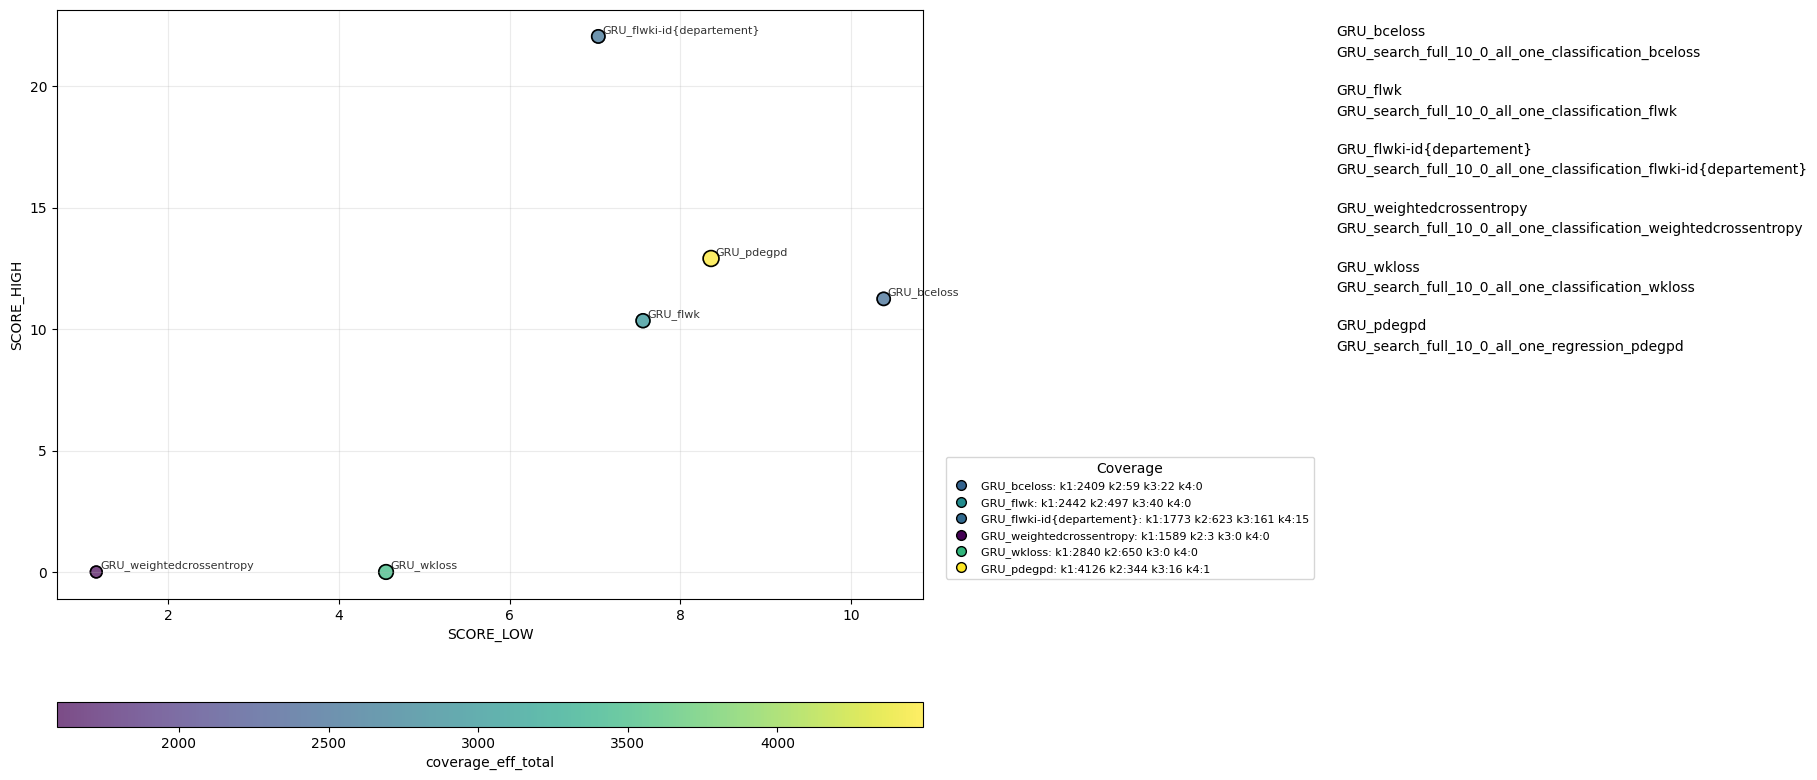

Index(['GRU_search_full_10_0_all_one_classification_bceloss',
       'GRU_search_full_10_0_all_one_classification_flwk',
       'GRU_search_full_10_0_all_one_classification_flwki-id{departement}',
       'GRU_search_full_10_0_all_one_classification_weightedcrossentropy',
       'GRU_search_full_10_0_all_one_classification_wkloss',
       'GRU_search_full_10_0_all_one_regression_pdegpd'],
      dtype='object')
#########################"
0 GRU_search_full_10_0_all_one_classification_bceloss
1 GRU_search_full_10_0_all_one_classification_flwk
2 GRU_search_full_10_0_all_one_classification_flwki-id{departement}
3 GRU_search_full_10_0_all_one_classification_weightedcrossentropy
4 GRU_search_full_10_0_all_one_classification_wkloss
5 GRU_search_full_10_0_all_one_regression_pdegpd
##############################
Index(['GRU_search_full_10_0_all_one_classification_bceloss',
       'GRU_search_full_10_0_all_one_classification_flwk',
       'GRU_search_full_10_0_all_one_classification_flwki-id{depar

NameError: name 'top2_agg' is not defined

In [112]:
from sklearn.preprocessing import MinMaxScaler

def min_max(df, target):
    if df is None:
        return None
    
    scaler = MinMaxScaler()
    df[target] = scaler.fit_transform(df[target].values.reshape(-1,1))
    return df

def run_pareto_top2_aggregation(
    data_frames: dict,
    TARGETS: dict,
    dfe_df_filter: pd.DataFrame,
    fire_df_filter: pd.DataFrame,
    res_df_filter: pd.DataFrame,
    time_df_filter: pd.DataFrame,
    dfe_df: pd.DataFrame,
    ba_df_filter: pd.DataFrame,
    *,
    apply_normalisation : bool = False,
    EXTRAPOLATION: bool = True,
    df_spline: int = 5,
    min_n: int = 1,
    agg_prefix: str = "All Model (H0)",
    keep_baselines: list | None = None,
    low_ks: tuple = (1, 2),
    high_ks: tuple = (3, 4),
    size_by: str = "coverage_eff_total",
    color_by: str = "coverage_eff_total",
    title: str = "Pareto (baselines + top2 aggregation only)",
):
    """
    Pipeline complet:
      - Concat risk_all (configs existantes)
      - Génère les nouvelles configs d'agrégation "All Model (H0)" (multi-preds)
      - Construit df_long par target (Fire/Res/Time + éventuellement DFE_score)
      - Estime all_metrics (passages k=1..4) par target
      - Standardise les deltas par sigma(Y)
      - Calcule coverage (0..4) + SCORE_LOW/HIGH
      - Filtre l'affichage: garde baselines + top-2 configs d'agrégation
      - Trace le Pareto

    Retourne:
      dict avec scores_lh_plot, coverage_plot, top2_agg, pareto_fig (si plot retourne fig), etc.
    """
    if keep_baselines is None:
        keep_baselines = ["DFE_score", "Model (H0)", 'FWI_score']
        
    # -----------------------------
    # Build risk_allscores_lh_plot
    # -----------------------------
    risk_all = pd.concat(data_frames.values(), ignore_index=True)

    # -----------------------------
    # Build master_pred (raw predictions)
    # -----------------------------
    #master_pred = build_master_pred_df(
    #    dfe_df_filter, fire_df_filter, res_df_filter, time_df_filter, ba_df_filter
    #)
    
    # -----------------------------
    # Build df_long per target
    # -----------------------------
    df_long_by_target = {}
    for target_name, (gt_df, y_col) in TARGETS.items():
        
        # Target-specific All Model (H0) using splines
        # We fit a spline for each component against the current target
        # Merge
        #m_target = master_pred.merge(
        #    gt_df[KEYS + [
        #        y_col,
        #        "nbsinister-kmeans-5-Class-Dept",
                #"ressource-kmeans-5-Class-Dept",
                #"timeintervention-kmeans-5-Class-Dept",
        #        "burnedareaRoot-kmeans-5-Class-Dept",
                #"prediction_DFE_0",
        #    ]],
        #    on=KEYS,
        #    how="inner"
        #)

        # Rename ALL problematic columns once
        #m_target = m_target.rename(columns={
        #    "nbsinister-kmeans-5-Class-Dept": "nbsinister_kmeans_5_class_dept",
            #"ressource-kmeans-5-Class-Dept": "ressource_kmeans_5_class_dept",
            #"timeintervention-kmeans-5-Class-Dept": "timeintervention_kmeans_5_class_dept"
        #    "burnedareaRoot-kmeans-5-Class-Dept": "burnedareaRoot_kmeans_5_class_dept"
        #})

        # w1Spline(fire) + w2Spline(ressource) + w3Spline(time) + w4Spline(dfe)
        #m_target["spline_fire"] = get_spline_prediction(
        #    m_target, "pred_fire", "nbsinister_kmeans_5_class_dept", df_spline
        #)

        #m_target["spline_res"] = get_spline_prediction(
        #    m_target, "pred_res", "ressource_kmeans_5_class_dept", df_spline
        #)

        #m_target["spline_time"] = get_spline_prediction(
        #    m_target, "pred_time", "timeintervention_kmeans_5_class_dept", df_spline
        #)

        #m_target["spline_dfe"] = get_spline_prediction(
        #    m_target, "prediction_DFE_0", "DFE", df_spline
        #)
        
        #m_target["spline_ba"] = get_spline_prediction(
        #    m_target, "pred_ba", "burnedareaRoot_kmeans_5_class_dept", df_spline
        #)
        
        #target_allmodel_long = build_allmodel_score_configs(
        #    m_target,
        #    fire_col="spline_fire",
        #    res_col="spline_res",
        #    time_col="spline_time",
        #    dfe_col="spline_dfe",
        #    ba_col="spline_ba"
        #)

        add_dfe = "DFE_score" in keep_baselines
        add_fwi = 'FWI_score' in keep_baselines

        df_long = prepare_long_for_target(
            risk_all, gt_df, y_col,
            add_dfe_score_as_config=add_dfe,
            add_fwi_score_as_config=add_fwi,
            dfe_df=dfe_df,
            dfe_config_name="DFE_score",
            fwi_config_name="FWI_score",
            extra_scores=None
        )
        df_long_by_target[target_name] = df_long

    # -----------------------------
    # Estimate passage metrics per target
    # -----------------------------
    all_metrics = {}
    for t, df_long in df_long_by_target.items():
        all_metrics[t] = estimate_passage_metrics_per_target(
            df_long, df_spline=df_spline, min_n=min_n, EXTRAPOLATION=EXTRAPOLATION
        )

    # -----------------------------
    # Standardise by sigma(Y) for each target
    # -----------------------------
    Y_std = {t: df_long_by_target[t]["Y"].std() for t in df_long_by_target}
    for t in all_metrics:
        sigma = Y_std[t]
        for k in LEVELS[1:]:
            all_metrics[t][f"avg_delta_{k}_STD"] = all_metrics[t][f"avg_delta_{k}"] / sigma
            all_metrics[t][f"min_delta_{k}_STD"] = all_metrics[t][f"min_delta_{k}"] / sigma
            all_metrics[t][f"neg_mass_{k}_STD"]  = all_metrics[t][f"neg_mass_{k}"] / sigma

    # -----------------------------
    # -----------------------------
    # Coverage 0..4 par config — MOYENNE SUR TOUTES LES TARGETS
    # -----------------------------
    coverage_list = []

    for t, df_long in df_long_by_target.items():
        df_for_cov = df_long[["date", "num_zone", "config", "score"]].copy()

        cov_t = compute_coverage_levels(
            df_for_cov,
            score_col="score",
            config_col="config"
        )

        # tag pour savoir d'où ça vient (debug utile)
        cov_t["target"] = t
        coverage_list.append(cov_t.reset_index())

    # Concat tous les coverages
    coverage_all_targets = pd.concat(coverage_list, ignore_index=True)

    # Moyenne par config sur les targets
    coverage = (
        coverage_all_targets
        .groupby("config")[
            [
                "coverage_eff_k1",
                "coverage_eff_k2",
                "coverage_eff_k3",
                "coverage_eff_k4",
            ]
        ]
        .mean()
    )

    # Total
    coverage["coverage_eff_total"] = (
        coverage["coverage_eff_k1"]
        + coverage["coverage_eff_k2"]
        + coverage["coverage_eff_k3"]
        + coverage["coverage_eff_k4"]
    )


    # -----------------------------
    # Scores LOW/HIGH (LOW=k1+k2, HIGH=k3+k4)
    # -----------------------------
    scores_lh = compute_score_low_high(
        all_metrics=all_metrics, mode="frt",
        low_ks=low_ks, high_ks=high_ks,
        use_adj=False
    )

    # -----------------------------
    # Keep only top-2 aggregation configs for plotting
    # -----------------------------
    scores_lh = scores_lh.copy()
    scores_lh["TOTAL"] = scores_lh["SCORE_LOW"] + scores_lh["SCORE_HIGH"]

    agg_cfgs = [c for c in scores_lh.index if str(c).startswith(agg_prefix)]

    # Garder aussi tout ce qui n’est PAS une config d’agrégation
    non_agg_cfgs = [c for c in scores_lh.index if not str(c).startswith(agg_prefix)]

    keep_cfgs = agg_cfgs
    scores_lh_plot = scores_lh.loc[[c for c in keep_cfgs if c in scores_lh.index]].copy()
    coverage_plot = coverage.loc[coverage.index.intersection(scores_lh_plot.index)].copy()

    # -----------------------------
    # Plot Pareto
    # -----------------------------
    pareto = plot_pareto_low_high(
        scores_lh_plot,
        coverage_df=coverage_plot,
        size_by=size_by,
        color_by=color_by,
        show_coverage_text="k",
        title=title,
        top2_agg=None
    )
    
    # 2) Coverage (sur un df_long adapté, ex: merged Fire/Res/Time etc.)
    # coverage_df = compute_coverage_levels(df_long_for_some_target_or_concat, ks=(1,2,3,4))

    # 3) LaTeX
    latex = pareto_low_high_to_latex_table(
        scores_low_high=scores_lh_plot,
        coverage_df=coverage_plot,     # optionnel
        only_pareto=True,            # comme ton plot (frontière)
        top_n=30,
        float_fmt="{:.2f}",
        skip_4=False,
        caption="Pareto SCORE\\_LOW vs SCORE\\_HIGH avec couvertures et SCORE\\_k.",
        label="tab:pareto_low_high",
    )
    
    return {
        "risk_all": risk_all,
        "master_pred": master_pred if 'master_pred' in locals() else None,
        "df_long_by_target": df_long_by_target,
        "all_metrics": all_metrics,
        "coverage": coverage,
        "scores_lh": scores_lh,
        "top2_agg": top2_agg,
        "scores_lh_plot": scores_lh_plot,
        "coverage_plot": coverage_plot,
        "pareto": pareto,
        "latex" : latex
    }
    
# -----------------------------
# Spline FE: mu(0..4) + passages (avec 4)
# -----------------------------
LEVELS = [0, 1, 2, 3, 4]

PASSAGES = {
    1: [(0,1), (1,2), (2,3), (3,4)],
    2: [(0,2), (1,3), (2,4)],
    3: [(0,3), (1,4)],
    4: [(0,4)],
}

TARGETS = {
    "Fire": (gt_dfs['nbsinister-kmeans-5-Class-Dept'], "nbsinister"),
}

EXTRAPOLATION = False

results = run_pareto_top2_aggregation(
    data_frames=data_frames,
    TARGETS=TARGETS,
    dfe_df_filter=None,
    fire_df_filter=gt_dfs['nbsinister-kmeans-5-Class-Dept'],
    res_df_filter=None,
    time_df_filter=None,
    #ba_df_filter=gt_dfs['burnedareaRoot-kmeans-5-Class-Dept'],
    ba_df_filter=None,
    dfe_df=None,                     # celui utilisé pour DFE_score
    EXTRAPOLATION=EXTRAPOLATION,
    df_spline=5,
    min_n=5,
    agg_prefix="",      # nom des configs d’agrégation
    keep_baselines=[],
    low_ks=(1, 2),
    high_ks=(3, 4),
    size_by="coverage_eff_total",
    color_by="coverage_eff_total",
    title=""
)

print("\nTop-2 aggregation configs retenues :")
for c in results["top2_agg"]:
    print("  ", c)

# Si tu veux récupérer les tables pour analyse ensuite :
scores_lh_plot = results["scores_lh_plot"]
coverage_plot  = results["coverage_plot"]
all_metrics    = results["all_metrics"]